# Week 6 — Day 2: Activations, Forward Propagation & Loss

**Project:** Stroke-Risk Prediction (capstone)
**Task:** Understand non-linear activations, forward propagation, and loss functions

---

## Objective

Explain why non-linear activations are essential, choose the correct activation for hidden vs. output layers, and describe forward propagation — including selecting the right loss function for the capstone's binary classification task.


## Lesson Content

### 2.1 — Why Activation Functions Matter

Without an activation function, a neural network — no matter how many layers — collapses into a single linear model, because a stack of linear operations is still linear. The activation function introduces **non-linearity**, which is what lets the network learn complex, curved patterns. It is the single ingredient that makes deep learning powerful.

### 2.2 — Common Activation Functions

| Function | Output Range | Use It For |
|---|---|---|
| ReLU | 0 to +∞ (negatives → 0) | Hidden layers — the default choice, fast and effective |
| Sigmoid | 0 to 1 | Output layer for binary classification (a probability) |
| Softmax | 0 to 1, sums to 1 | Output layer for multi-class classification (class probabilities) |
| Tanh | -1 to +1 | Hidden layers when zero-centered output helps |

**The practical rule:** use ReLU in hidden layers by default, and choose the output activation by the task — sigmoid for binary, softmax for multi-class, and none (linear) for regression.

### 2.3 — Forward Propagation

Forward propagation is the network *making a prediction*: data enters the input layer and flows forward, each layer computing its weighted sums and activations, until the output layer produces a prediction. It is the network running "forward" to answer — exactly what happens at prediction time, and the first half of every training step.

```python
# Forward pass, conceptually:
# layer1 = ReLU(dot(X, W1) + b1)
# layer2 = ReLU(dot(layer1, W2) + b2)
# output = sigmoid(dot(layer2, W3) + b3)
```

### 2.4 — The Loss Function

After a forward pass, the loss function measures how wrong the prediction was by comparing it to the true label. A high loss means bad predictions; the entire goal of training is to make the loss as small as possible. The right loss depends on the task:

| Task | Loss Function |
|---|---|
| Regression | Mean Squared Error (MSE) |
| Binary classification | Binary cross-entropy |
| Multi-class classification | Categorical cross-entropy |

Since the capstone (stroke prediction) is **binary classification**, the output layer uses a **sigmoid** activation and **binary cross-entropy** loss.


---

## Hands-On Lab: Activations & the Forward Pass

1. Plot ReLU, sigmoid, and tanh over a range of inputs to see how each transforms values.
2. For the Phase 3 project task, decide the correct output activation and loss function, and justify both.
3. By hand or in NumPy, compute one forward pass for a tiny 2-layer network on a sample input.
4. Document the choices and the forward-pass result in Markdown.

**Tools:** NumPy, Matplotlib, Jupyter/Colab


### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Step 1: Plot ReLU, Sigmoid, and Tanh

Visualizing how each activation transforms a range of inputs makes the differences concrete: ReLU zeroes out negatives and passes positives through unchanged; sigmoid squashes everything into (0, 1); tanh squashes into (-1, 1) and is zero-centered.


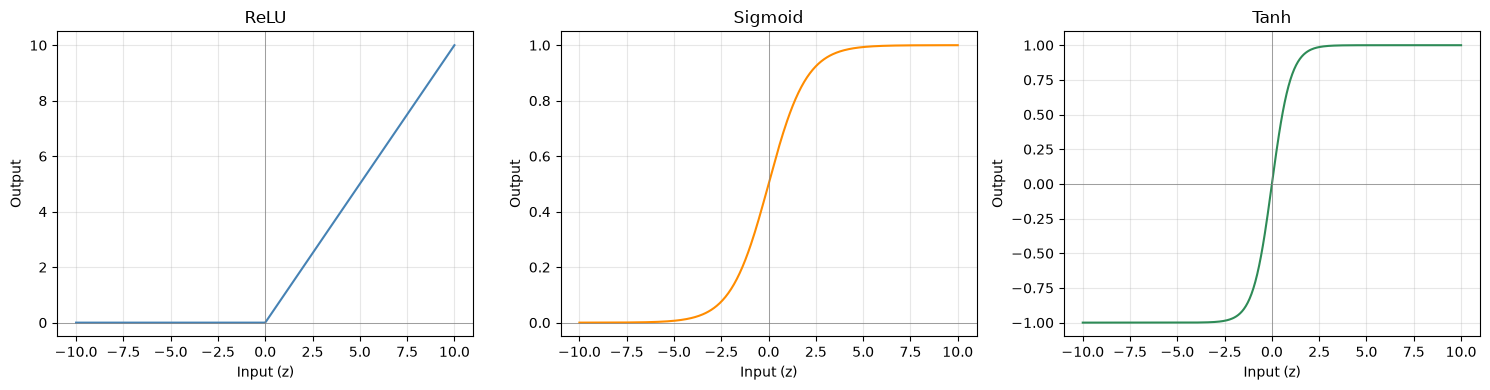

In [2]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

x = np.linspace(-10, 10, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, relu(x), color="steelblue")
axes[0].set_title("ReLU")
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].axvline(0, color="gray", lw=0.5)

axes[1].plot(x, sigmoid(x), color="darkorange")
axes[1].set_title("Sigmoid")
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].axvline(0, color="gray", lw=0.5)

axes[2].plot(x, tanh(x), color="seagreen")
axes[2].set_title("Tanh")
axes[2].axhline(0, color="gray", lw=0.5)
axes[2].axvline(0, color="gray", lw=0.5)

for ax in axes:
    ax.set_xlabel("Input (z)")
    ax.set_ylabel("Output")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Step 2: Choosing the Output Activation & Loss for the Capstone

**Task:** Stroke prediction is **binary classification** (stroke: 0 or 1).

**Output activation:** **Sigmoid** — squashes the final weighted sum into a (0, 1) probability, matching a binary target and pairing naturally with a probability threshold (e.g. 0.5, though Sprint 1's baseline already showed threshold choice matters for recall on the minority class).

**Loss function:** **Binary cross-entropy** — penalizes confident wrong predictions heavily and directly measures the distance between predicted probability and the true 0/1 label, exactly as required for binary classification.

**Hidden layers:** **ReLU** — the default choice for hidden layers, fast to compute and avoids the vanishing-gradient problems of sigmoid/tanh when stacked across multiple layers.


### Step 3: Manual Forward Pass — Tiny 2-Layer Network

Using one sample from the stroke dataset's numeric features (age, avg_glucose_level, bmi — standardized), compute a forward pass through a tiny network by hand with NumPy: `Input(3) → Hidden(4, ReLU) → Output(1, Sigmoid)`.


In [3]:
# Toy weights/biases (random init, fixed here for reproducibility)
rng = np.random.default_rng(42)

# Sample input: 3 standardized features (age, avg_glucose_level, bmi)
X_sample = np.array([0.85, 1.42, -0.30])  # a single patient, already scaled

# Layer 1: Input(3) -> Hidden(4), ReLU
W1 = rng.normal(0, 0.5, size=(3, 4))
b1 = np.zeros(4)

# Layer 2: Hidden(4) -> Output(1), Sigmoid
W2 = rng.normal(0, 0.5, size=(4, 1))
b2 = np.zeros(1)

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Forward pass
z1 = np.dot(X_sample, W1) + b1
a1 = relu(z1)
print("Hidden layer pre-activation (z1):", z1)
print("Hidden layer post-ReLU (a1):     ", a1)

z2 = np.dot(a1, W2) + b2
a2 = sigmoid(z2)
print("\nOutput pre-activation (z2):", z2)
print("Predicted probability (a2):", a2)


Hidden layer pre-activation (z1): [-1.25321005 -1.23858411  0.27779875  0.05853897]
Hidden layer post-ReLU (a1):      [0.         0.         0.27779875 0.05853897]

Output pre-activation (z2): [0.03978571]
Predicted probability (a2): [0.50994511]


In [4]:
# Loss for this single prediction, assuming the true label is 1 (patient had a stroke)
y_true = 1

def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

loss = binary_cross_entropy(y_true, a2[0])
print(f"Predicted probability: {a2[0]:.4f}")
print(f"True label: {y_true}")
print(f"Binary cross-entropy loss: {loss:.4f}")


Predicted probability: 0.5099
True label: 1
Binary cross-entropy loss: 0.6735


### Step 4: Documented Choices & Forward-Pass Result

- **Hidden layer activation:** ReLU — default, fast, avoids vanishing gradients.
- **Output activation:** Sigmoid — matches the binary stroke/no-stroke target with a probability output.
- **Loss function:** Binary cross-entropy — the standard loss for binary classification, penalizing confident wrong predictions.
- **Forward pass result (this run):** two of the four hidden neurons had negative pre-activations (`z1 = [-1.253, -1.239, 0.278, 0.059]`) and were zeroed out by ReLU (`a1 = [0, 0, 0.278, 0.059]`) — a direct example of ReLU's "negatives → 0" behavior. The output layer produced `a2 = 0.5099`, essentially a coin-flip probability, since the weights are still random and untrained. Against the true label (`y_true = 1`), this gives a binary cross-entropy loss of **0.6735** — close to `-log(0.5) ≈ 0.693`, the expected loss of a network that is basically guessing. This confirms the network hasn't learned anything yet, which is exactly the starting point Day 3 (backpropagation and gradient descent) is designed to fix: those steps use this loss to update `W1`, `b1`, `W2`, `b2` and push `a2` toward `1`, driving the loss down.